In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Subset
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.OxfordIIITPet(
    root="data",
    download=True,
    target_types="segmentation",
    transform=transform,
    target_transform=transforms.Compose([
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ])
)

small_data = Subset(dataset, range(20))
loader = DataLoader(small_data, batch_size=1)

100%|██████████| 792M/792M [00:36<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.5MB/s]


In [3]:
conv1 = nn.Conv2d(3,16,3,padding=1)
conv2 = nn.Conv2d(16,16,3,padding=1)

pool = nn.MaxPool2d(2)

conv3 = nn.Conv2d(16,32,3,padding=1)

up = nn.ConvTranspose2d(32,16,2,stride=2)

conv4 = nn.Conv2d(32,16,3,padding=1)

out = nn.Conv2d(16,1,1)

relu = nn.ReLU()


In [4]:
params = list(conv1.parameters())+list(conv2.parameters())+list(conv3.parameters())+list(conv4.parameters())+list(out.parameters())+list(up.parameters())

optimizer = torch.optim.Adam(params, lr=0.001)

loss_fn = nn.BCEWithLogitsLoss()

In [5]:
for image, mask in loader:

    mask = mask.float()

    x1 = relu(conv1(image))
    x1 = relu(conv2(x1))

    p = pool(x1)

    x2 = relu(conv3(p))

    u = up(x2)

    cat = torch.cat((u,x1),dim=1)

    x3 = relu(conv4(cat))

    output = out(x3)

    mask = torch.nn.functional.interpolate(mask,size=output.shape[2:])

    loss = loss_fn(output,mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Loss:",loss.item())

Loss: 0.06320223212242126


In [6]:
pred = torch.sigmoid(output)
pred = (pred>0.5).float()

intersection = (pred*mask).sum()
union = pred.sum()+mask.sum()-intersection

iou = intersection/union

print("IoU:",iou.item())

IoU: 0.0


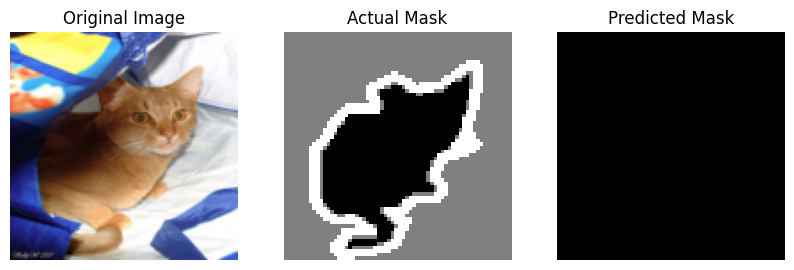

In [7]:
import matplotlib.pyplot as plt

# take one sample
image, mask = next(iter(loader))

mask = mask.float()

# forward pass
x1 = relu(conv1(image))
x1 = relu(conv2(x1))

p = pool(x1)

x2 = relu(conv3(p))

u = up(x2)

cat = torch.cat((u, x1), dim=1)

x3 = relu(conv4(cat))

output = out(x3)

# prediction
pred = torch.sigmoid(output)
pred = (pred > 0.5).float()

# remove batch dimension
image = image[0].permute(1,2,0)   # C,H,W → H,W,C
mask = mask[0][0]
pred = pred[0][0]

# plot
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Actual Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred.detach(), cmap='gray')
plt.axis("off")

plt.show()